In [67]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

DICIONÁRIO DE VARIÁVEIS

O dataset contém as seguintes variáveis:

show_id — identificador único (string)

type — Movie ou TV Show

title — título

director — nome(s) do(s) diretor(es)

cast — elenco

country — país(es) de produção

date_added — data de inclusão na Netflix

release_year — ano de lançamento

rating — classificação indicativa

duration — duração (minutos ou número de temporadas)

listed_in — categorias/genres

description — descrição do título

1) DESCREVER OS DADOS

1.1) Quais são os tipos de variáveis?

Tem por objetivo identificar se cada coluna é:

numérica (int, float)

categórica (object)

data (datetime)

texto livre

booleana

Esse procedimento ajuda a saber como tratar cada coluna.

In [68]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

1.2) Quantos valores nulos existem?

Para verificar onde há dados faltantes e mostra:

colunas com muitos nulos

colunas sem nulos

colunas que talvez precisem ser removidas ou preenchidas

In [69]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

1.3) Quantos valores distintos existem?

A informação revela:

- colunas com pouca variação (podem ser inúteis)

- colunas com muita variação (podem ser identificadores)

- colunas categóricas com muitos níveis

In [70]:
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

1.4) O df.shape retorna uma tupla e responde duas coisas essenciais:

- Quantos registros existem no DataFrame

- Quantas variáveis/colunas ele possui

É uma forma rápida de entender o tamanho da base.

In [71]:
df.shape

(8807, 12)

1.5) Como os dados estão distribuídos?

Isso ajuda a entender:

valores mais comuns

outliers

padrões iniciais

Para variáveis numéricas:

In [72]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Para categóricas:

In [73]:
lista = df.columns.tolist()
lista = [col for col in lista if col != "release_year"]
print(lista)

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']


In [74]:
df[lista].value_counts()

show_id  type   title                  director                          cast                                                                                                                                                                       country                                        date_added          rating  duration  listed_in                                         description                                                                                                                                            
s10      Movie  The Starling           Theodore Melfi                    Melissa McCarthy, Chris O'Dowd, Kevin Kline, Timothy Olyphant, Daveed Diggs, Skyler Gisondo, Laura Harrier, Rosalind Chao, Kimberly Quinn, Loretta Devine, Ravi Kapoor     United States                                  September 24, 2021  PG-13   104 min   Comedies, Dramas                                  A woman adjusting to life after a loss contends with a feisty bird that's taken over her g

1.6) O df.info() é uma das funções mais importantes da análise exploratória porque ele te dá um raio‑X rápido e objetivo do seu dataset. Ele responde, de uma vez só, várias das perguntas que normalmente aparecem na etapa de descrição dos dados.

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


2) Fazer o tratamento de qualidade dos dados (Remover nulos, remover valores constantes, ...)

In [76]:

# remover duplicatas com base em todas as colunas (se houver)
df = df.drop_duplicates()

# remover colunas com valores constantes (se houver)
for col in df.columns:
    if df[col].nunique() == 1:
        df = df.drop(columns=[col])

# tratar nulos, exluindo os registros onde forem nulos
df = df.dropna(subset=["director", "cast", "country", "rating"])

# separar duração numérica e tipo (minutos ou temporadas)
df["duration_value"] = df["duration"].str.extract(r"(\d+)")
df["duration_unit"] = df["duration"].str.extract(r"([A-Za-z]+)")
df["duration_value"] = df["duration_value"].astype(float)

# converter datas
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")



* Nova situação dos dados após o tratamento

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5335 entries, 7 to 8806
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         5335 non-null   object        
 1   type            5335 non-null   object        
 2   title           5335 non-null   object        
 3   director        5335 non-null   object        
 4   cast            5335 non-null   object        
 5   country         5335 non-null   object        
 6   date_added      5331 non-null   datetime64[ns]
 7   release_year    5335 non-null   int64         
 8   rating          5335 non-null   object        
 9   duration        5332 non-null   object        
 10  listed_in       5335 non-null   object        
 11  description     5335 non-null   object        
 12  duration_value  5332 non-null   float64       
 13  duration_unit   5332 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(11)
memory

3) Levantar 5 perguntas sobre o dataset e responder utilizado filtragens, agrupamentos e transformações no Pandas.


3.1) Quantos filmes e séries existem no catálogo?

In [78]:
df["type"].value_counts()

type
Movie      5188
TV Show     147
Name: count, dtype: int64

2) Quais são os 10 países com mais produções?

In [79]:
#preciso criar um dataframe para contar os países, pois a coluna 'country' 
#pode conter múltiplos países separados por vírgula.
lista_paises = df['country'].str.split(',', expand=True)
print(lista_paises.head(10))

                 0                1               2                3  \
7    United States            Ghana    Burkina Faso   United Kingdom   
8   United Kingdom             None            None             None   
9    United States             None            None             None   
12         Germany   Czech Republic            None             None   
24           India             None            None             None   
27   United States             None            None             None   
28   United States             None            None             None   
29   United States            India          France             None   
38           China           Canada   United States             None   
41   United States             None            None             None   

           4          5     6     7  
7    Germany   Ethiopia  None  None  
8       None       None  None  None  
9       None       None  None  None  
12      None       None  None  None  
24      None     

In [80]:
lista_paises_estack = lista_paises.stack()
print(lista_paises_estack.head(10))

7   0      United States
    1              Ghana
    2       Burkina Faso
    3     United Kingdom
    4            Germany
    5           Ethiopia
8   0     United Kingdom
9   0      United States
12  0            Germany
    1     Czech Republic
dtype: object


In [81]:
lista_paises.stack().value_counts().head(10)

United States      2133
India               910
 United States      355
United Kingdom      347
Canada              166
 France             148
France              145
 United Kingdom     138
 Canada             129
Spain               122
Name: count, dtype: int64

3) Qual o ano com mais lançamentos (release_year)?

In [82]:
df["release_year"].value_counts().head(10)


release_year
2017    658
2018    648
2016    577
2019    519
2020    442
2015    350
2014    242
2013    197
2012    163
2021    161
Name: count, dtype: int64

<Axes: xlabel='release_year'>

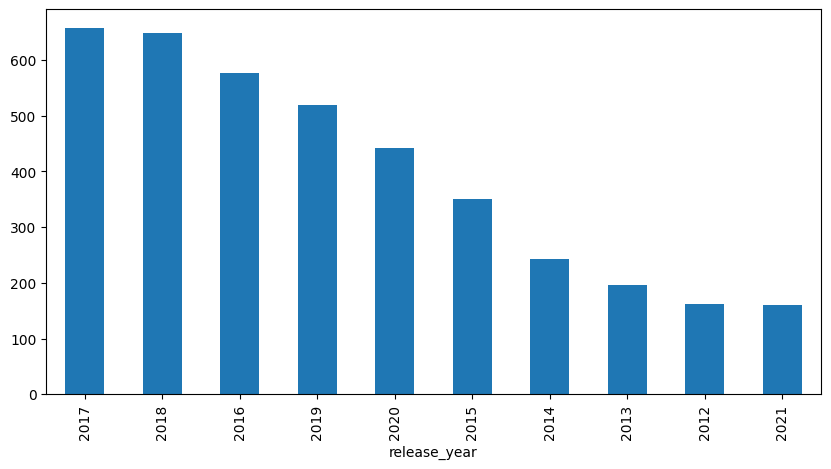

In [83]:
df['release_year'].value_counts().head(10).plot(kind='bar', figsize=(10,5))

4) Quais são os gêneros mais comuns (listed_in)?

In [84]:
lista_genero = df['listed_in'].str.split(',', expand=True)
print(lista_genero.head(10))

                     0                      1                      2
7               Dramas     Independent Movies   International Movies
8     British TV Shows             Reality TV                   None
9             Comedies                 Dramas                   None
12              Dramas   International Movies                   None
24            Comedies   International Movies        Romantic Movies
27            Comedies                   None                   None
28       Horror Movies       Sci-Fi & Fantasy                   None
29           Thrillers                   None                   None
38  Action & Adventure                 Dramas                   None
41  Action & Adventure         Classic Movies                 Dramas


In [85]:
lista_genero.stack().value_counts().head(10)

 International Movies       2260
Dramas                      1518
Comedies                    1127
Action & Adventure           806
 Dramas                      775
 Independent Movies          720
 Romantic Movies             576
 Thrillers                   485
Children & Family Movies     469
 Comedies                    426
Name: count, dtype: int64

5) Qual é a duração média dos filmes?

In [86]:
movies = df[df["type"] == "Movie"]
movies["duration_value"].mean()


np.float64(102.70144648023144)